In [1]:
# PyTorch core
import torch
import torch.nn as nn
import torch.optim as optim

# Data handling (already used in task a, but safe to include)
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Utilities
import pandas as pd
import itertools
import matplotlib.pyplot as plt

### Data import

In [8]:
IMG_SIZE = (64, 64) #IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_dir = "icosimal_img_class_03/data_uniform_224_224_sets/train"
val_dir = "icosimal_img_class_03/data_uniform_224_224_sets/validate"

# Transforms
train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor()
])

# Datasets
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(root=val_dir, transform=val_transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Class names
class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Classes: ['cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'rabbit', 'sheep', 'squirrel', 'zebra']
Number of classes: 10


### a) Start from simple CNN architectures and progressively increase their complexity to show the benefit of depth

In [4]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [5]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [6]:
class CNN_1(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(16 * 4 * 4, num_classes)
        )

#        self.classifier = nn.Sequential(
#            nn.Flatten(),
#            nn.Linear(16 * 64 * 64, num_classes)
#        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [7]:
class CNN_2(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.0):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(32 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes)
        )

#        self.classifier = nn.Sequential(
#            nn.Flatten(),
#            nn.Linear(32 * 32 * 32, 128),
#            nn.ReLU(),
#            nn.Linear(128, num_classes)
#        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [20]:
class CNN_3(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.0):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )

#        self.classifier = nn.Sequential(
#            nn.Flatten(),
#            nn.Linear(64 * 16 * 16, 256),
#            nn.ReLU(),
#            nn.Linear(256, num_classes)
#        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

NEW CODE to replace upper code

In [10]:
print("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

models = {
    "CNN_1": CNN_1(num_classes),
    "CNN_2": CNN_2(num_classes),
    "CNN_3": CNN_3(num_classes)
}

criterion = nn.CrossEntropyLoss()

results = []

for name, model in models.items():
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    print(f"\nTraining {name}...")

    best_val_acc = 0

    for epoch in range(10):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        best_val_acc = max(best_val_acc, val_acc)

        print(f"{name} | Epoch {epoch+1}/10")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.4f}")

    # store final results
    results.append({
        "model": name,
        "final_train_loss": train_loss,
        "final_train_acc": train_acc,
        "final_val_loss": val_loss,
        "final_val_acc": val_acc,
        "best_val_acc": best_val_acc
    })

# -------------------------
# Create comparison table
# -------------------------
results_df = pd.DataFrame(results)

print("\n=== Model Comparison ===")
display(results_df.sort_values(by="best_val_acc", ascending=False))

cuda

Training CNN_1...
CNN_1 | Epoch 1/10
Train Loss: 2.1874, Train Acc: 0.2030
Val   Loss: 2.0912, Val   Acc: 0.2547
CNN_1 | Epoch 2/10
Train Loss: 2.0373, Train Acc: 0.2878
Val   Loss: 2.0325, Val   Acc: 0.2698
CNN_1 | Epoch 3/10
Train Loss: 1.9701, Train Acc: 0.3159
Val   Loss: 1.9508, Val   Acc: 0.3280
CNN_1 | Epoch 4/10
Train Loss: 1.9211, Train Acc: 0.3343
Val   Loss: 1.9117, Val   Acc: 0.3403
CNN_1 | Epoch 5/10
Train Loss: 1.8857, Train Acc: 0.3513
Val   Loss: 1.8800, Val   Acc: 0.3527
CNN_1 | Epoch 6/10
Train Loss: 1.8479, Train Acc: 0.3675
Val   Loss: 1.8526, Val   Acc: 0.3602
CNN_1 | Epoch 7/10
Train Loss: 1.8162, Train Acc: 0.3754
Val   Loss: 1.8194, Val   Acc: 0.3717
CNN_1 | Epoch 8/10
Train Loss: 1.7879, Train Acc: 0.3878
Val   Loss: 1.7950, Val   Acc: 0.3858
CNN_1 | Epoch 9/10
Train Loss: 1.7657, Train Acc: 0.3943
Val   Loss: 1.7640, Val   Acc: 0.3990
CNN_1 | Epoch 10/10
Train Loss: 1.7438, Train Acc: 0.4044
Val   Loss: 1.7655, Val   Acc: 0.3957

Training CNN_2...
CNN_2 

,model,final_train_loss,final_train_acc,final_val_loss,final_val_acc,best_val_acc
2,CNN_3,0.953700,0.668833,1.201228,0.590167,0.590167
1,CNN_2,1.265783,0.560042,1.323983,0.549500,0.549500
0,CNN_1,1.743794,0.404417,1.765483,0.395667,0.399000


### b) Show the importance of hyperparameter tuning.

In [11]:
learning_rates = [0.001, 0.0001]
dropout_rates = [0.0, 0.3, 0.5]
optimizers_list = ["Adam", "RMSprop"]
batch_sizes = [32, 64]

num_epochs = 5

grid = list(itertools.product(
    learning_rates,
    dropout_rates,
    optimizers_list,
    batch_sizes
))

print("Total experiments:", len(grid))
print(grid[:5])  # preview first few combinations

Total experiments: 24
[(0.001, 0.0, 'Adam', 32), (0.001, 0.0, 'Adam', 64), (0.001, 0.0, 'RMSprop', 32), (0.001, 0.0, 'RMSprop', 64), (0.001, 0.3, 'Adam', 32)]


In [12]:
class CNN_3_Tunable(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.0):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [13]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=5):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(num_epochs):
        # ---- Training ----
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total

        # ---- Validation ----
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * images.size(0)
                preds = outputs.argmax(dim=1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()

        val_loss = running_loss / total
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
        )

    return history


In [14]:
results = []
all_histories = {}

for i, (lr, dropout_rate, optimizer_name, batch_size) in enumerate(grid, start=1):
    print("\n" + "=" * 70)
    print(f"Experiment {i}/{len(grid)}")
    print(f"learning_rate={lr}, dropout={dropout_rate}, optimizer={optimizer_name}, batch_size={batch_size}")

    model = CNN_3_Tunable(num_classes=num_classes, dropout_rate=dropout_rate).to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == "RMSprop":
        optimizer = optim.RMSprop(model.parameters(), lr=lr)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")

    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_epochs=num_epochs
    )

    config_name = f"lr={lr}_dropout={dropout_rate}_opt={optimizer_name}_bs={batch_size}"
    all_histories[config_name] = history

    results.append({
        "learning_rate": lr,
        "dropout": dropout_rate,
        "optimizer": optimizer_name,
        "batch_size": batch_size,
        "final_train_loss": history["train_loss"][-1],
        "final_train_acc": history["train_acc"][-1],
        "final_val_loss": history["val_loss"][-1],
        "final_val_acc": history["val_acc"][-1],
        "best_val_acc": max(history["val_acc"]),
        "best_val_loss": min(history["val_loss"])
    })

results_df = pd.DataFrame(results)


Experiment 1/24
learning_rate=0.001, dropout=0.0, optimizer=Adam, batch_size=32
Epoch 1/5 | Train Loss: 1.9748, Train Acc: 0.2925 | Val Loss: 1.7640, Val Acc: 0.3718
Epoch 2/5 | Train Loss: 1.6127, Train Acc: 0.4365 | Val Loss: 1.4846, Val Acc: 0.4743
Epoch 3/5 | Train Loss: 1.4523, Train Acc: 0.4909 | Val Loss: 1.4011, Val Acc: 0.5173
Epoch 4/5 | Train Loss: 1.3529, Train Acc: 0.5312 | Val Loss: 1.3357, Val Acc: 0.5380
Epoch 5/5 | Train Loss: 1.2604, Train Acc: 0.5620 | Val Loss: 1.2666, Val Acc: 0.5643

Experiment 2/24
learning_rate=0.001, dropout=0.0, optimizer=Adam, batch_size=64
Epoch 1/5 | Train Loss: 1.9571, Train Acc: 0.3017 | Val Loss: 1.7283, Val Acc: 0.3990
Epoch 2/5 | Train Loss: 1.6311, Train Acc: 0.4260 | Val Loss: 1.5268, Val Acc: 0.4618
Epoch 3/5 | Train Loss: 1.4641, Train Acc: 0.4873 | Val Loss: 1.4150, Val Acc: 0.5087
Epoch 4/5 | Train Loss: 1.3512, Train Acc: 0.5272 | Val Loss: 1.3198, Val Acc: 0.5420
Epoch 5/5 | Train Loss: 1.2621, Train Acc: 0.5605 | Val Loss: 1.

In [15]:
# ---- Full sorted result table ----
results_sorted = results_df.sort_values(by="best_val_acc", ascending=False)
display(results_sorted)

# ---- Best configuration ----
best_result = results_sorted.iloc[0]

print("Best configuration:")
display(best_result.to_frame())

# ---- Pivot table / matrix view ----
pivot_table = results_df.pivot_table(
    index="optimizer",
    columns=["learning_rate", "dropout", "batch_size"],
    values="best_val_acc"
)

print("Pivot table of best validation accuracy:")
display(pivot_table)

# ---- Average result by optimizer ----
optimizer_summary = results_df.groupby("optimizer")[["best_val_acc", "final_val_acc", "final_val_loss"]].mean()
print("Average performance per optimizer:")
display(optimizer_summary)

# ---- Save results if needed ----
results_df.to_csv("cnn3_grid_search_results.csv", index=False)
print("Results saved to cnn3_grid_search_results.csv")

,learning_rate,dropout,optimizer,batch_size,final_train_loss,final_train_acc,final_val_loss,final_val_acc,best_val_acc,best_val_loss
0,0.0010,0.0,Adam,32,1.260370,0.562000,1.266586,0.564333,0.564333,1.266586
2,0.0010,0.0,RMSprop,32,1.265455,0.558667,1.296199,0.546167,0.546167,1.296199
1,0.0010,0.0,Adam,64,1.262073,0.560542,1.296098,0.543500,0.543500,1.296098
5,0.0010,0.3,Adam,64,1.368491,0.522000,1.363552,0.535333,0.535333,1.363552
7,0.0010,0.3,RMSprop,64,1.362572,0.526125,1.327602,0.530833,0.530833,1.327602
11,0.0010,0.5,RMSprop,64,1.432787,0.502208,1.358872,0.529500,0.529500,1.358872
10,0.0010,0.5,RMSprop,32,1.446425,0.498208,1.374366,0.528833,0.528833,1.374366
4,0.0010,0.3,Adam,32,1.359586,0.528667,1.367281,0.524333,0.524333,1.367281
6,0.0010,0.3,RMSprop,32,1.368153,0.523083,1.360061,0.523333,0.523333,1.360061
3,0.0010,0.0,RMSprop,64,1.305703,0.546042,1.370810,0.517833,0.517833,1.370810


Best configuration:


,0
learning_rate,0.001
dropout,0.0
optimizer,Adam
batch_size,32
final_train_loss,1.26037
final_train_acc,0.562
final_val_loss,1.266586
final_val_acc,0.564333
best_val_acc,0.564333
best_val_loss,1.266586


Pivot table of best validation accuracy:


learning_rate    0.0001                                                    \
dropout             0.0                 0.3                 0.5             
batch_size           32        64        32        64        32        64   
optimizer                                                                   
Adam           0.401167  0.389333  0.383333  0.367333  0.380667  0.359167   
RMSprop        0.348167  0.361167  0.370833  0.356333  0.361000  0.354000   

learning_rate    0.0010                                                    
dropout             0.0                 0.3                 0.5            
batch_size           32        64        32        64        32        64  
optimizer                                                                  
Adam           0.564333  0.543500  0.524333  0.535333  0.516500  0.517167  
RMSprop        0.546167  0.517833  0.523333  0.530833  0.528833  0.529500

Average performance per optimizer:


,best_val_acc,final_val_acc,final_val_loss
optimizer,,,
Adam,0.456847,0.456847,1.560439
RMSprop,0.444000,0.444000,1.590985


Results saved to cnn3_grid_search_results.csv


### c) Show models that overfit and underfit and explain the reasons for that. 

### d) Experiment with regularization techniques.

In [16]:
class CNN_3_Regularized(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.0):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [17]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=10):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(num_epochs):
        # Training
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total

        # Validation
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * images.size(0)
                preds = outputs.argmax(dim=1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()

        val_loss = running_loss / total
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
        )

    return history

In [18]:
regularization_configs = [
    {"name": "Baseline", "dropout": 0.0, "weight_decay": 0.0},
    {"name": "Dropout", "dropout": 0.5, "weight_decay": 0.0},
    {"name": "WeightDecay", "dropout": 0.0, "weight_decay": 1e-4},
    {"name": "Dropout+WeightDecay", "dropout": 0.5, "weight_decay": 1e-4},
]

num_epochs = 10
criterion = nn.CrossEntropyLoss()

results = []
histories = {}

for config in regularization_configs:
    print("\n" + "=" * 60)
    print(f"Running: {config['name']}")
    print(f"dropout={config['dropout']}, weight_decay={config['weight_decay']}")

    model = CNN_3_Regularized(
        num_classes=num_classes,
        dropout_rate=config["dropout"]
    ).to(device)

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001,
        weight_decay=config["weight_decay"]
    )

    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_epochs=num_epochs
    )

    histories[config["name"]] = history

    results.append({
        "config": config["name"],
        "dropout": config["dropout"],
        "weight_decay": config["weight_decay"],
        "final_train_loss": history["train_loss"][-1],
        "final_train_acc": history["train_acc"][-1],
        "final_val_loss": history["val_loss"][-1],
        "final_val_acc": history["val_acc"][-1],
        "best_val_acc": max(history["val_acc"]),
        "best_val_loss": min(history["val_loss"])
    })

results_df = pd.DataFrame(results)


Running: Baseline
dropout=0.0, weight_decay=0.0
Epoch 1/10 | Train Loss: 2.0834, Train Acc: 0.2394 | Val Loss: 1.8337, Val Acc: 0.3525
Epoch 2/10 | Train Loss: 1.7396, Train Acc: 0.3852 | Val Loss: 1.6515, Val Acc: 0.4120
Epoch 3/10 | Train Loss: 1.5724, Train Acc: 0.4504 | Val Loss: 1.5551, Val Acc: 0.4522
Epoch 4/10 | Train Loss: 1.4455, Train Acc: 0.4955 | Val Loss: 1.4363, Val Acc: 0.5025
Epoch 5/10 | Train Loss: 1.3488, Train Acc: 0.5292 | Val Loss: 1.3540, Val Acc: 0.5287
Epoch 6/10 | Train Loss: 1.2648, Train Acc: 0.5640 | Val Loss: 1.3183, Val Acc: 0.5373
Epoch 7/10 | Train Loss: 1.1926, Train Acc: 0.5889 | Val Loss: 1.3067, Val Acc: 0.5452
Epoch 8/10 | Train Loss: 1.1246, Train Acc: 0.6103 | Val Loss: 1.3215, Val Acc: 0.5480
Epoch 9/10 | Train Loss: 1.0553, Train Acc: 0.6345 | Val Loss: 1.2768, Val Acc: 0.5627
Epoch 10/10 | Train Loss: 0.9925, Train Acc: 0.6584 | Val Loss: 1.2592, Val Acc: 0.5605

Running: Dropout
dropout=0.5, weight_decay=0.0
Epoch 1/10 | Train Loss: 2.0400,

In [19]:
results_sorted = results_df.sort_values(by="best_val_acc", ascending=False)

print("Regularization comparison:")
display(results_sorted)

Regularization comparison:


,config,dropout,weight_decay,final_train_loss,final_train_acc,final_val_loss,final_val_acc,best_val_acc,best_val_loss
1,Dropout,0.5,0.0000,1.199411,0.582500,1.215184,0.582833,0.582833,1.215184
3,Dropout+WeightDecay,0.5,0.0001,1.249701,0.567458,1.244231,0.569000,0.569000,1.244231
2,WeightDecay,0.0,0.0001,1.066389,0.632000,1.258893,0.565000,0.565000,1.258893
0,Baseline,0.0,0.0000,0.992527,0.658375,1.259232,0.560500,0.562667,1.259232


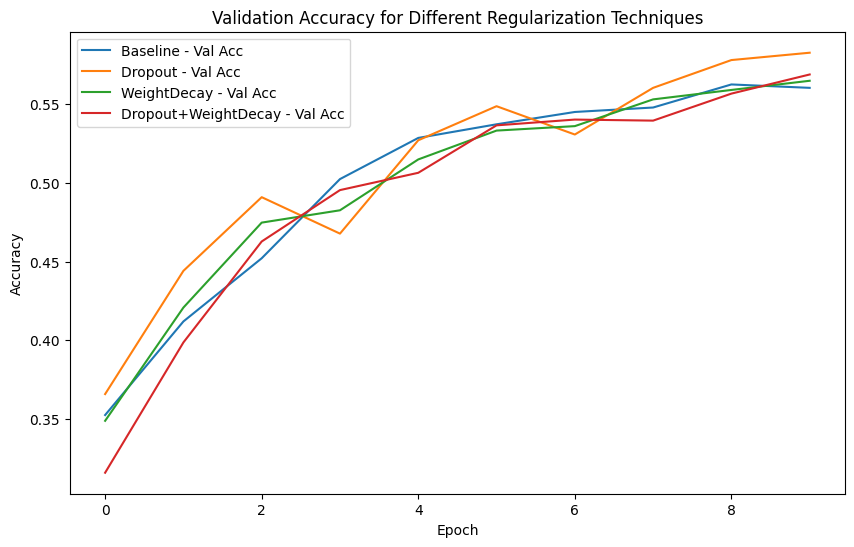

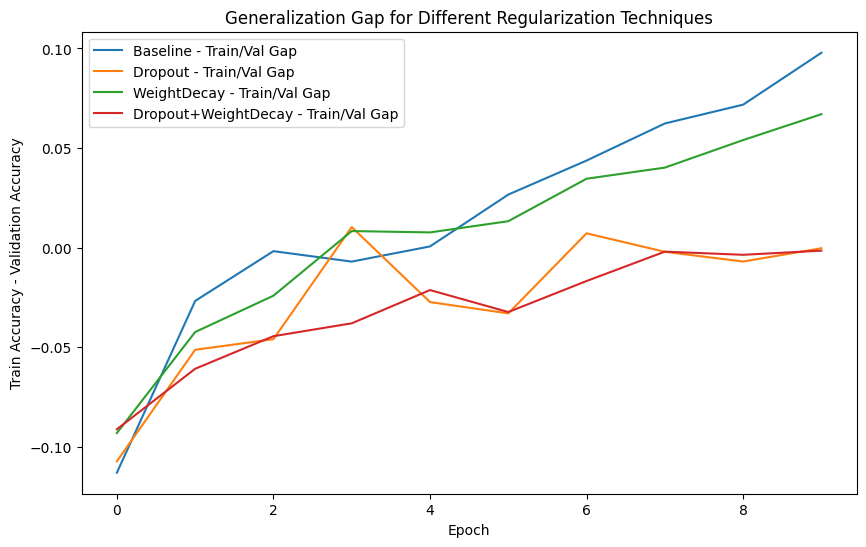

In [21]:
plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(history["val_acc"], label=f"{name} - Val Acc")

plt.title("Validation Accuracy for Different Regularization Techniques")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))

for name, history in histories.items():
    gap = [train - val for train, val in zip(history["train_acc"], history["val_acc"])]
    plt.plot(gap, label=f"{name} - Train/Val Gap")

plt.title("Generalization Gap for Different Regularization Techniques")
plt.xlabel("Epoch")
plt.ylabel("Train Accuracy - Validation Accuracy")
plt.legend()
plt.show()

### e) Experiment with different optimization algorithms (e.g., Adam, RMSprop) and compare their performance.

In [22]:
optimizer_configs = [
    {"name": "Adam", "lr": 0.001},
    {"name": "RMSprop", "lr": 0.001},
    {"name": "SGD", "lr": 0.01, "momentum": 0.9}
]

num_epochs = 10

In [23]:
class CNN_3_Optim(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.0):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [24]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=10):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(num_epochs):
        # ---- Training ----
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total

        # ---- Validation ----
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * images.size(0)
                preds = outputs.argmax(dim=1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()

        val_loss = running_loss / total
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
        )

    return history


criterion = nn.CrossEntropyLoss()

results = []
histories = {}

for config in optimizer_configs:
    print("\n" + "=" * 60)
    print(f"Running optimizer: {config['name']}")

    model = CNN_3_Optim(num_classes=num_classes, dropout_rate=0.0).to(device)

    if config["name"] == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=config["lr"])
    elif config["name"] == "RMSprop":
        optimizer = optim.RMSprop(model.parameters(), lr=config["lr"])
    elif config["name"] == "SGD":
        optimizer = optim.SGD(
            model.parameters(),
            lr=config["lr"],
            momentum=config["momentum"]
        )
    else:
        raise ValueError(f"Unsupported optimizer: {config['name']}")

    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_epochs=num_epochs
    )

    histories[config["name"]] = history

    results.append({
        "optimizer": config["name"],
        "learning_rate": config["lr"],
        "final_train_loss": history["train_loss"][-1],
        "final_train_acc": history["train_acc"][-1],
        "final_val_loss": history["val_loss"][-1],
        "final_val_acc": history["val_acc"][-1],
        "best_val_acc": max(history["val_acc"]),
        "best_val_loss": min(history["val_loss"])
    })

results_df = pd.DataFrame(results)


Running optimizer: Adam
Epoch 1/10 | Train Loss: 1.9727, Train Acc: 0.2868 | Val Loss: 1.7205, Val Acc: 0.3862
Epoch 2/10 | Train Loss: 1.6541, Train Acc: 0.4188 | Val Loss: 1.5859, Val Acc: 0.4368
Epoch 3/10 | Train Loss: 1.4928, Train Acc: 0.4776 | Val Loss: 1.4448, Val Acc: 0.4935
Epoch 4/10 | Train Loss: 1.3776, Train Acc: 0.5193 | Val Loss: 1.4259, Val Acc: 0.4947
Epoch 5/10 | Train Loss: 1.2933, Train Acc: 0.5512 | Val Loss: 1.3250, Val Acc: 0.5358
Epoch 6/10 | Train Loss: 1.2103, Train Acc: 0.5768 | Val Loss: 1.3082, Val Acc: 0.5483
Epoch 7/10 | Train Loss: 1.1366, Train Acc: 0.6008 | Val Loss: 1.2416, Val Acc: 0.5702
Epoch 8/10 | Train Loss: 1.0790, Train Acc: 0.6257 | Val Loss: 1.2371, Val Acc: 0.5722
Epoch 9/10 | Train Loss: 1.0110, Train Acc: 0.6485 | Val Loss: 1.2293, Val Acc: 0.5818
Epoch 10/10 | Train Loss: 0.9509, Train Acc: 0.6699 | Val Loss: 1.2630, Val Acc: 0.5795

Running optimizer: RMSprop
Epoch 1/10 | Train Loss: 1.9732, Train Acc: 0.2897 | Val Loss: 1.7270, Val A

In [25]:
# ---- Sorted result table ----
results_sorted = results_df.sort_values(by="best_val_acc", ascending=False)

print("Optimizer comparison:")
display(results_sorted)

# ---- Best optimizer ----
best_result = results_sorted.iloc[0]

print("Best optimizer configuration:")
display(best_result.to_frame())

Optimizer comparison:


,optimizer,learning_rate,final_train_loss,final_train_acc,final_val_loss,final_val_acc,best_val_acc,best_val_loss
0,Adam,0.001,0.950858,0.669917,1.263013,0.5795,0.581833,1.229333
1,RMSprop,0.001,0.957922,0.670542,1.314858,0.5490,0.576500,1.240491
2,SGD,0.010,1.018487,0.644667,1.264997,0.5670,0.567000,1.264997


Best optimizer configuration:


,0
optimizer,Adam
learning_rate,0.001
final_train_loss,0.950858
final_train_acc,0.669917
final_val_loss,1.263013
final_val_acc,0.5795
best_val_acc,0.581833
best_val_loss,1.229333


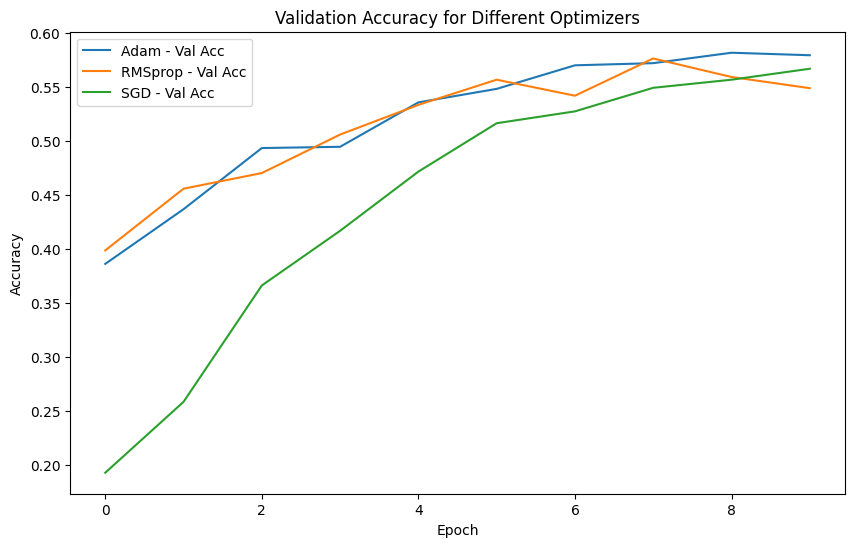

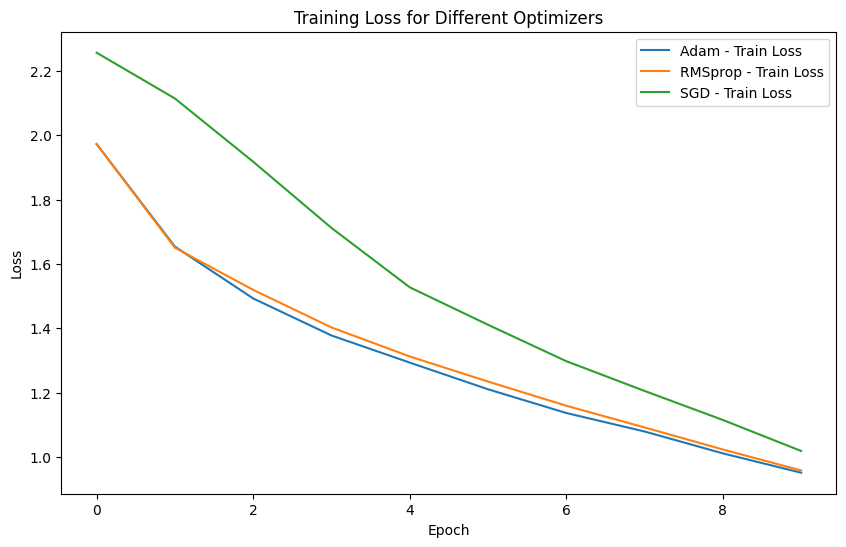

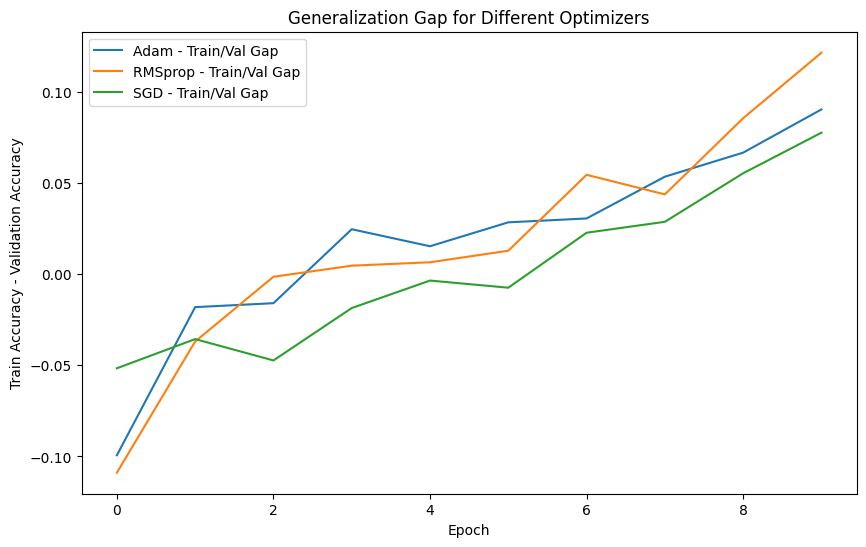

In [26]:
plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(history["val_acc"], label=f"{name} - Val Acc")

plt.title("Validation Accuracy for Different Optimizers")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(history["train_loss"], label=f"{name} - Train Loss")

plt.title("Training Loss for Different Optimizers")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))

for name, history in histories.items():
    gap = [train - val for train, val in zip(history["train_acc"], history["val_acc"])]
    plt.plot(gap, label=f"{name} - Train/Val Gap")

plt.title("Generalization Gap for Different Optimizers")
plt.xlabel("Epoch")
plt.ylabel("Train Accuracy - Validation Accuracy")
plt.legend()
plt.show()

### Perform transfer learning using pre-trained models and compare their performance with models trained from scratch

In [13]:
import torch
import torch.nn as nn
from torchvision import models

def get_resnet18_scratch(num_classes):
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def get_resnet18_pretrained_frozen(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    for param in model.parameters():
        param.requires_grad = False

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def get_resnet18_pretrained_finetune(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

In [14]:
import torch.optim as optim
import pandas as pd

def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=10):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(num_epochs):
        # Training
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total

        # Validation
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * images.size(0)
                preds = outputs.argmax(dim=1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()

        val_loss = running_loss / total
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
        )

    return history

In [15]:
criterion = nn.CrossEntropyLoss()
num_epochs = 10

experiment_configs = [
    {"name": "ResNet18_Scratch", "type": "scratch", "lr": 0.001},
    {"name": "ResNet18_Pretrained_Frozen", "type": "pretrained_frozen", "lr": 0.001},
    {"name": "ResNet18_Pretrained_Finetune", "type": "pretrained_finetune", "lr": 0.0001},
]

results = []
histories = {}

for config in experiment_configs:
    print("\n" + "=" * 70)
    print(f"Running: {config['name']}")

    if config["type"] == "scratch":
        model = get_resnet18_scratch(num_classes)
    elif config["type"] == "pretrained_frozen":
        model = get_resnet18_pretrained_frozen(num_classes)
    elif config["type"] == "pretrained_finetune":
        model = get_resnet18_pretrained_finetune(num_classes)
    else:
        raise ValueError(f"Unknown config type: {config['type']}")

    model = model.to(device)

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=config["lr"]
    )

    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_epochs=num_epochs
    )

    histories[config["name"]] = history

    results.append({
        "model": config["name"],
        "learning_rate": config["lr"],
        "final_train_loss": history["train_loss"][-1],
        "final_train_acc": history["train_acc"][-1],
        "final_val_loss": history["val_loss"][-1],
        "final_val_acc": history["val_acc"][-1],
        "best_val_acc": max(history["val_acc"]),
        "best_val_loss": min(history["val_loss"])
    })

results_df = pd.DataFrame(results)


Running: ResNet18_Scratch
Epoch 1/10 | Train Loss: 1.8213, Train Acc: 0.3566 | Val Loss: 1.6942, Val Acc: 0.3958
Epoch 2/10 | Train Loss: 1.4459, Train Acc: 0.4978 | Val Loss: 1.8029, Val Acc: 0.3868
Epoch 3/10 | Train Loss: 1.2636, Train Acc: 0.5680 | Val Loss: 1.4817, Val Acc: 0.5125
Epoch 4/10 | Train Loss: 1.0980, Train Acc: 0.6219 | Val Loss: 1.5532, Val Acc: 0.4945
Epoch 5/10 | Train Loss: 0.9440, Train Acc: 0.6755 | Val Loss: 1.3559, Val Acc: 0.5450
Epoch 6/10 | Train Loss: 0.7674, Train Acc: 0.7332 | Val Loss: 1.4058, Val Acc: 0.5503
Epoch 7/10 | Train Loss: 0.5869, Train Acc: 0.7967 | Val Loss: 1.4146, Val Acc: 0.5697
Epoch 8/10 | Train Loss: 0.4058, Train Acc: 0.8615 | Val Loss: 1.4500, Val Acc: 0.5972
Epoch 9/10 | Train Loss: 0.2778, Train Acc: 0.9052 | Val Loss: 1.4905, Val Acc: 0.6102
Epoch 10/10 | Train Loss: 0.1876, Train Acc: 0.9361 | Val Loss: 1.7136, Val Acc: 0.5947

Running: ResNet18_Pretrained_Frozen
Epoch 1/10 | Train Loss: 1.6265, Train Acc: 0.4436 | Val Loss: 1.

In [16]:
results_sorted = results_df.sort_values(by="best_val_acc", ascending=False)

print("Transfer learning comparison:")
display(results_sorted)

best_result = results_sorted.iloc[0]

print("Best configuration:")
display(best_result.to_frame())

Transfer learning comparison:


,model,learning_rate,final_train_loss,final_train_acc,final_val_loss,final_val_acc,best_val_acc,best_val_loss
2,ResNet18_Pretrained_Finetune,0.0001,0.077741,0.973417,1.003876,0.774000,0.781167,0.706830
0,ResNet18_Scratch,0.0010,0.187632,0.936125,1.713617,0.594667,0.610167,1.355857
1,ResNet18_Pretrained_Frozen,0.0010,1.419562,0.520792,1.446448,0.523000,0.527000,1.413814


Best configuration:


,2
model,ResNet18_Pretrained_Finetune
learning_rate,0.0001
final_train_loss,0.077741
final_train_acc,0.973417
final_val_loss,1.003876
final_val_acc,0.774
best_val_acc,0.781167
best_val_loss,0.70683


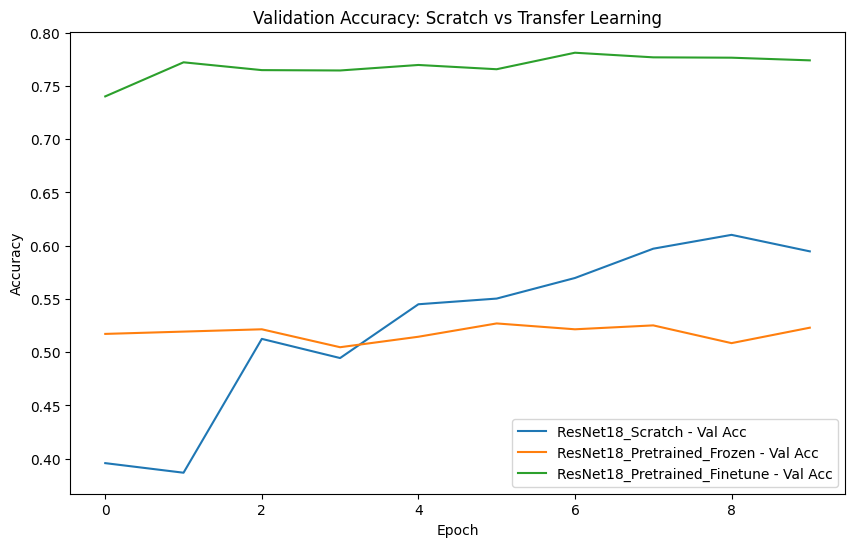

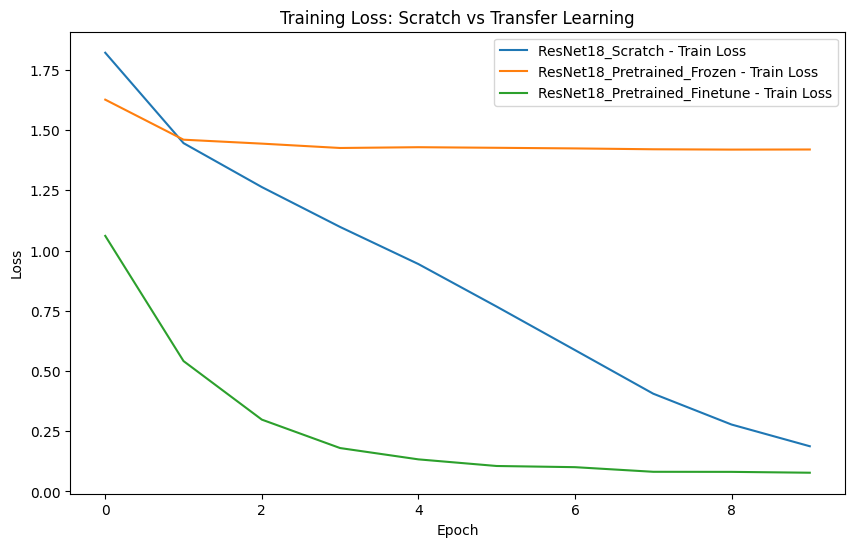

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(history["val_acc"], label=f"{name} - Val Acc")

plt.title("Validation Accuracy: Scratch vs Transfer Learning")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(history["train_loss"], label=f"{name} - Train Loss")

plt.title("Training Loss: Scratch vs Transfer Learning")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### — Use advanced architectures (e.g., ResNet, DenseNet) and compare their performance with simpler architectures.

In [21]:
import torch
import torch.nn as nn
from torchvision import models

def get_resnet18(num_classes):
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def get_densenet121(num_classes):
    model = models.densenet121(weights=None)
    model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    return model

In [22]:
models_to_compare = {
    "CNN_3": CNN_3(num_classes),
    "ResNet18": get_resnet18(num_classes),
    "DenseNet121": get_densenet121(num_classes)
}

In [23]:
import torch.optim as optim
import pandas as pd

def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=10):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(num_epochs):
        # ---- Training ----
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total

        # ---- Validation ----
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * images.size(0)
                preds = outputs.argmax(dim=1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()

        val_loss = running_loss / total
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
        )

    return history

In [24]:
criterion = nn.CrossEntropyLoss()
num_epochs = 10
learning_rate = 0.001

results = []
histories = {}

for name, model in models_to_compare.items():
    print("\n" + "=" * 70)
    print(f"Training {name}")

    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_epochs=num_epochs
    )

    histories[name] = history

    results.append({
        "model": name,
        "final_train_loss": history["train_loss"][-1],
        "final_train_acc": history["train_acc"][-1],
        "final_val_loss": history["val_loss"][-1],
        "final_val_acc": history["val_acc"][-1],
        "best_val_acc": max(history["val_acc"]),
        "best_val_loss": min(history["val_loss"])
    })

results_df = pd.DataFrame(results)


Training CNN_3
Epoch 1/10 | Train Loss: 1.9824, Train Acc: 0.2878 | Val Loss: 1.7205, Val Acc: 0.3928
Epoch 2/10 | Train Loss: 1.6080, Train Acc: 0.4397 | Val Loss: 1.5677, Val Acc: 0.4490
Epoch 3/10 | Train Loss: 1.4231, Train Acc: 0.5033 | Val Loss: 1.3706, Val Acc: 0.5253
Epoch 4/10 | Train Loss: 1.3032, Train Acc: 0.5471 | Val Loss: 1.3640, Val Acc: 0.5305
Epoch 5/10 | Train Loss: 1.2052, Train Acc: 0.5829 | Val Loss: 1.3142, Val Acc: 0.5513
Epoch 6/10 | Train Loss: 1.1135, Train Acc: 0.6141 | Val Loss: 1.2087, Val Acc: 0.5852
Epoch 7/10 | Train Loss: 1.0349, Train Acc: 0.6440 | Val Loss: 1.2710, Val Acc: 0.5728
Epoch 8/10 | Train Loss: 0.9526, Train Acc: 0.6719 | Val Loss: 1.2401, Val Acc: 0.5802
Epoch 9/10 | Train Loss: 0.8776, Train Acc: 0.7007 | Val Loss: 1.1993, Val Acc: 0.5895
Epoch 10/10 | Train Loss: 0.8095, Train Acc: 0.7223 | Val Loss: 1.2200, Val Acc: 0.6012

Training ResNet18
Epoch 1/10 | Train Loss: 1.8185, Train Acc: 0.3631 | Val Loss: 1.6631, Val Acc: 0.4217
Epoch 2

In [25]:
results_sorted = results_df.sort_values(by="best_val_acc", ascending=False)

print("Architecture comparison:")
display(results_sorted)

best_result = results_sorted.iloc[0]

print("Best model:")
display(best_result.to_frame())

Architecture comparison:


,model,final_train_loss,final_train_acc,final_val_loss,final_val_acc,best_val_acc,best_val_loss
2,DenseNet121,0.411984,0.856958,1.192392,0.671333,0.679000,0.999572
1,ResNet18,0.193440,0.935167,1.785021,0.599833,0.615333,1.166595
0,CNN_3,0.809524,0.722333,1.220008,0.601167,0.601167,1.199323


Best model:


,2
model,DenseNet121
final_train_loss,0.411984
final_train_acc,0.856958
final_val_loss,1.192392
final_val_acc,0.671333
best_val_acc,0.679
best_val_loss,0.999572


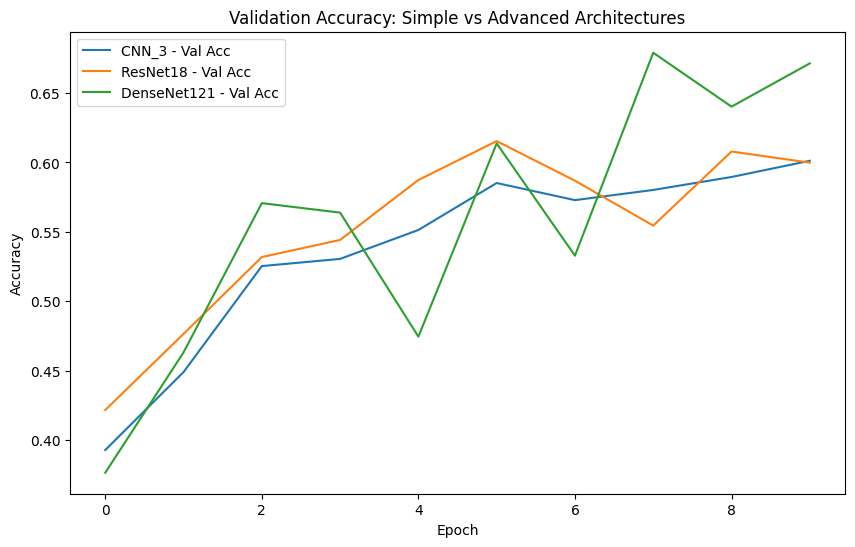

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(history["val_acc"], label=f"{name} - Val Acc")

plt.title("Validation Accuracy: Simple vs Advanced Architectures")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

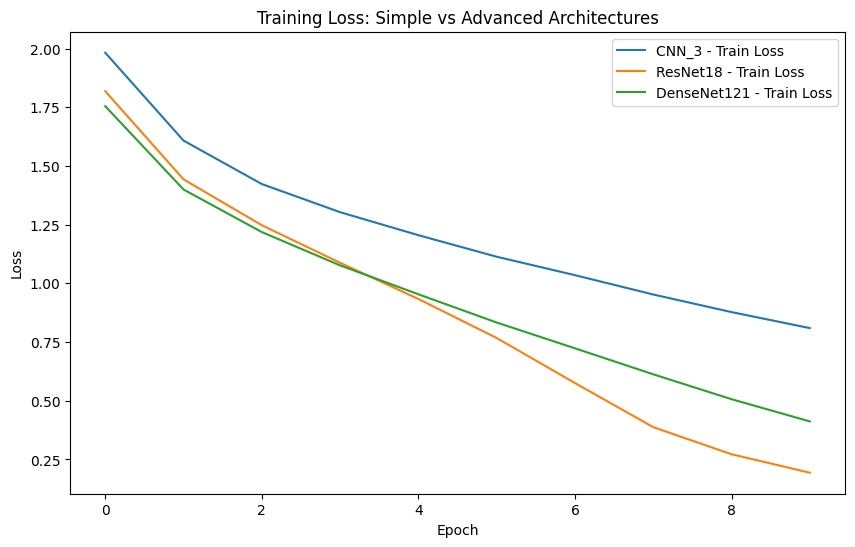

In [27]:
plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(history["train_loss"], label=f"{name} - Train Loss")

plt.title("Training Loss: Simple vs Advanced Architectures")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()